# Local End-to-End Prototyping Notebook

This notebook runs the **entire forecasting project locally** using the **same `src/forecasting` code** that the deployed Vertex AI pipelines use. It is the fastest way to prototype changes and verify that what you build here will behave identically once compiled and submitted serverlessly.

**What it does (mirrors the two production pipelines):**
1. **Generate data** — synthetic base + drifted demand series (`forecasting.data`).
2. **Pipeline 1 (local)** — build features, split reference/current, run drift detection (`local_runner.run_data_pipeline_local`).
3. **Pipeline 2 (local)** — train Ridge + Random Forest, build inverse-RMSE weighted ensemble (`local_runner.run_training_pipeline_local`).

> No GCP calls. No cost. Same logic as production.

## 0. Setup
This notebook is meant to be launched from the project environment created by `uv`. From the repo root run once:
```bash
uv sync --extra data --extra notebook --extra serving
uv run jupyter lab notebooks/local_end_to_end.ipynb
```
The `serving` extra adds FastAPI + uvicorn, needed by section 6 (hosting the endpoint locally). The kernel then already has every dependency (Evidently, matplotlib, scikit-learn, FastAPI, ...). No `pip install` needed.

In [1]:
# Make the src/ package importable when running the notebook from repo root or notebooks/.
import sys
from pathlib import Path

repo_root = Path.cwd()
if (repo_root / "src").exists():
    pass
elif (repo_root.parent / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / "src"))
print("repo_root:", repo_root)

repo_root: c:\Users\sanket_shetye\Downloads\source\gcp


## 1. Generate a synthetic dataset (base + drift)
Uses `forecasting.data.generate_base_and_drift` — the exact generator behind `scripts/generate_data.py`.

In [2]:
from forecasting.data import (
    SeriesConfig,
    DriftConfig,
    generate_base_and_drift,
    to_pipeline_frame,
)

base_cfg = SeriesConfig(start_date="2023-01-01", n_days=365, base_level=80.0, seed=42)
drift_cfg = DriftConfig(level_scale=1.4, extra_trend_per_day=0.2, noise_scale=2.5, seed=7)

base_df, drift_df, full_raw = generate_base_and_drift(base_cfg, drift_cfg)
print(f"base rows: {len(base_df)}, drift rows: {len(drift_df)}, full rows: {len(full_raw)}")
full_raw.head()

base rows: 365, drift rows: 365, full rows: 730


,sale_date,units_sold
0,2023-01-01,83.01
1,2023-01-02,76.58
2,2023-01-03,93.52
3,2023-01-04,96.99
4,2023-01-05,79.32


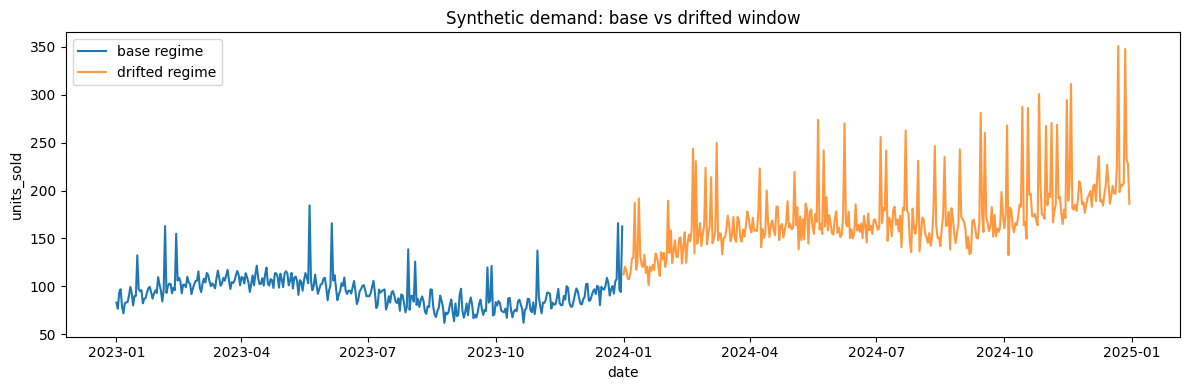

In [3]:
# Quick visual of the base vs drifted regime.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(base_df["sale_date"], base_df["units_sold"], label="base regime")
ax.plot(drift_df["sale_date"], drift_df["units_sold"], label="drifted regime", alpha=0.8)
ax.set_title("Synthetic demand: base vs drifted window")
ax.set_xlabel("date"); ax.set_ylabel("units_sold"); ax.legend()
plt.tight_layout(); plt.show()

Convert the raw `(sale_date, units_sold)` frame to the pipeline grain `(ds, demand)` — this is what the BigQuery mart produces in production.

In [4]:
pipeline_df = to_pipeline_frame(full_raw)
# The drifted window begins the day after the base ends:
split_date = str(drift_df["sale_date"].iloc[0])
print("drift split_date:", split_date)
pipeline_df.head()

drift split_date: 2024-01-01


,ds,demand
0,2023-01-01,83.01
1,2023-01-02,76.58
2,2023-01-03,93.52
3,2023-01-04,96.99
4,2023-01-05,79.32


## 2. Pipeline 1 (local): features → reference/current split → drift
`run_data_pipeline_local` mirrors `pipelines/data_pipeline.py`.

In [5]:
from forecasting.local_runner import run_data_pipeline_local

data_result = run_data_pipeline_local(
    raw_df=pipeline_df,
    split_date=split_date,
    out_dir=str(repo_root / "data" / "local_run"),
)
print("feature rows:", len(data_result.features))
print("reference rows:", len(data_result.reference), "| current rows:", len(data_result.current))
print("\nDrift summary:")
print("  dataset_drift        :", data_result.drift_summary.get("dataset_drift"))
print("  n_drifted_features   :", data_result.drift_summary.get("number_of_drifted_columns"))
print("  drift report         :", data_result.drift_report_path)

feature rows: 702
reference rows: 337 | current rows: 365

Drift summary:
  dataset_drift        : True
  n_drifted_features   : 8
  drift report         : c:\Users\sanket_shetye\Downloads\source\gcp\data\local_run\drift_report.html


In [ ]:
data_result.features.head()

## 3. Pipeline 2 (local): parallel training + weighted ensemble
`run_training_pipeline_local` mirrors `pipelines/training_pipeline.py` — independent per-model fits (the parallel branches) then an inverse-RMSE weighted fan-in ensemble.

In [6]:
from forecasting.local_runner import run_training_pipeline_local

training_result = run_training_pipeline_local(
    features=data_result.features,
    val_fraction=0.2,
    out_dir=str(repo_root / "data" / "local_run"),
)

import pandas as pd
print("Per-model validation metrics:")
display(pd.DataFrame(training_result.per_model_metrics).T)
print("\nEnsemble weights (inverse-RMSE):", training_result.weights)
print("Ensemble metrics:", training_result.ensemble_metrics)
print("Serialized model:", training_result.model_path)

Per-model validation metrics:


,mae,rmse,mape
ridge,22.159859,38.080710,10.198750
random_forest,26.663335,42.930234,12.156628



Ensemble weights (inverse-RMSE): {'ridge': 0.5299312899810574, 'random_forest': 0.4700687100189427}
Ensemble metrics: {'rmse': 39.31191521153575, 'mae': 22.234752370046337, 'mape': 10.018594584179533}
Serialized model: c:\Users\sanket_shetye\Downloads\source\gcp\data\local_run\ensemble_model.pkl


## 4. One-call end-to-end (exactly how production chains the two pipelines)

In [7]:
from forecasting.local_runner import run_end_to_end_local, summarize
import json

e2e = run_end_to_end_local(
    raw_df=pipeline_df,
    split_date=split_date,
    val_fraction=0.2,
    out_dir=str(repo_root / "data" / "local_run"),
)
print(json.dumps(summarize(e2e), indent=2, default=str))

{
  "drift": {
    "dataset_drift": true,
    "n_drifted_features": 8
  },
  "per_model_metrics": {
    "ridge": {
      "mae": 22.159859298949083,
      "rmse": 38.08070968302693,
      "mape": 10.198750290692754
    },
    "random_forest": {
      "mae": 26.663335388840277,
      "rmse": 42.93023376299021,
      "mape": 12.156627603709726
    }
  },
  "ensemble_weights": {
    "ridge": 0.5299312899810574,
    "random_forest": 0.4700687100189427
  },
  "ensemble_metrics": {
    "rmse": 39.31191521153575,
    "mae": 22.234752370046337,
    "mape": 10.018594584179533
  },
  "model_path": "c:\\Users\\sanket_shetye\\Downloads\\source\\gcp\\data\\local_run\\ensemble_model.pkl"
}


## 5. Load the serialized ensemble and predict (parity with the deployed model bundle)

In [8]:
import pickle
import numpy as np

with open(e2e.training.model_path, "rb") as fh:
    bundle = pickle.load(fh)

feats = data_result.features
cols = bundle["feature_cols"]
X = feats[cols].tail(10).to_numpy()

pred = np.zeros(len(X))
for member in bundle["members"]:
    pred += member["weight"] * member["estimator"].predict(X)

print("Ensemble members:", [(m["model_name"], round(m["weight"], 3)) for m in bundle["members"]])
print("Last-10 predictions:", np.round(pred, 2))

Ensemble members: [('ridge', 0.53), ('random_forest', 0.47)]
Last-10 predictions: [199.79 199.43 188.75 188.98 189.65 189.19 189.75 199.03 200.89 198.09]


## 6. Host the FastAPI serving endpoint locally
This is the **exact** `forecasting.serving.app` FastAPI app that ships to Cloud Run (see `deployment/serving/deploy_service.py`). We point it at the ensemble pickle we just trained via the `SERVING_MODEL_URI` env var and run `uvicorn` in a background thread so the notebook stays interactive.

**Endpoints exposed:**
- `GET  /healthz`  &mdash; liveness probe (does NOT load the model)
- `GET  /metadata` &mdash; ensemble metrics + member weights
- `POST /predict`  &mdash; recursive multi-step forecast from a supplied history
- `GET  /`         &mdash; single-page demo UI (form + Chart.js)

> The model is loaded **lazily** on the first `/predict` or `/metadata` call, so `/healthz` returns instantly.

In [9]:
import os
import time
import threading

import uvicorn

# Point the serving app at the ensemble bundle produced by the end-to-end run above.
os.environ["SERVING_MODEL_URI"] = str(e2e.training.model_path)

# Import AFTER setting the env var, and reset the process-level model cache so a
# fresh model is loaded on first request (important when re-running this cell).
from forecasting.serving import app as app_module
app_module._MODEL = None

HOST, PORT = "127.0.0.1", 8000
BASE_URL = f"http://{HOST}:{PORT}"


def _serve():
    uvicorn.run(app_module.app, host=HOST, port=PORT, log_level="warning")


# Start uvicorn in a daemon thread so the notebook cell returns immediately.
server_thread = threading.Thread(target=_serve, daemon=True)
server_thread.start()
time.sleep(1.5)  # give the server a moment to bind the port
print(f"Serving model: {os.environ['SERVING_MODEL_URI']}")
print(f"FastAPI running at {BASE_URL}")
print(f"Interactive docs (Swagger UI): {BASE_URL}/docs")
print(f"Demo UI:                       {BASE_URL}/")

Serving model: c:\Users\sanket_shetye\Downloads\source\gcp\data\local_run\ensemble_model.pkl
FastAPI running at http://127.0.0.1:8000
Interactive docs (Swagger UI): http://127.0.0.1:8000/docs
Demo UI:                       http://127.0.0.1:8000/


### 6.1 Smoke-test the health probe and inspect the model metadata

In [10]:
import json
import urllib.request


def api_get(path):
    with urllib.request.urlopen(f"{BASE_URL}{path}", timeout=30) as r:
        return json.loads(r.read())


def api_post(path, payload):
    req = urllib.request.Request(
        f"{BASE_URL}{path}",
        data=json.dumps(payload).encode(),
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    try:
        with urllib.request.urlopen(req, timeout=60) as r:
            return r.status, json.loads(r.read())
    except urllib.error.HTTPError as e:
        return e.code, json.loads(e.read())


print("GET /healthz ->", api_get("/healthz"))

meta = api_get("/metadata")
print("\nGET /metadata ->")
print(json.dumps(meta, indent=2))

GET /healthz -> {'status': 'ok'}

GET /metadata ->
{
  "type": "weighted_ensemble",
  "feature_cols": [
    "lag_1",
    "lag_7",
    "lag_14",
    "roll_mean_7",
    "roll_std_7",
    "roll_mean_28",
    "roll_std_28",
    "dayofweek",
    "month",
    "is_weekend"
  ],
  "metrics": {
    "rmse": 39.31191521153575,
    "mae": 22.234752370046337,
    "mape": 10.018594584179533
  },
  "members": [
    {
      "model_name": "ridge",
      "weight": 0.5299312899810574
    },
    {
      "model_name": "random_forest",
      "weight": 0.4700687100189427
    }
  ]
}


### 6.2 Sample inputs to try
The `/predict` payload is `{ "history": [{"ds", "demand"}, ...], "horizon": N }`.

**Important:** the features use lags up to 14 days and a 28-day rolling window, so the history must contain **at least ~29 rows** (aim for 30+) or the API returns HTTP 422. Below are three ready-to-run samples.

**Sample A** &mdash; reuse the real synthetic tail we already generated (guaranteed long enough).

In [11]:
# Sample A: last 60 observed days from the pipeline frame -> forecast 7 days ahead.
tail = pipeline_df.tail(60)
history_a = [
    {"ds": str(pd.Timestamp(ds).date()), "demand": float(v)}
    for ds, v in zip(tail["ds"], tail["demand"])
]
payload_a = {"history": history_a, "horizon": 7}

status, body = api_post("/predict", payload_a)
assert status == 200, (status, body)
print("horizon:", body["horizon"])
print("model_metrics:", body["model_metrics"])
print("forecast:")
for point in body["forecast"]:
    print(f"  {point['ds']}  ->  {point['demand']:.2f}")

horizon: 7
model_metrics: {'rmse': 39.31191521153575, 'mae': 22.234752370046337, 'mape': 10.018594584179533}
forecast:
  2024-12-31  ->  194.48
  2025-01-01  ->  192.30
  2025-01-02  ->  190.40
  2025-01-03  ->  189.55
  2025-01-04  ->  193.45
  2025-01-05  ->  196.13
  2025-01-06  ->  212.30


c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib

**Sample B** &mdash; a hand-written synthetic history (35 days). Handy as a copy-paste template for your own inputs.

In [12]:
# Sample B: build 35 days of gently-rising demand starting 2024-01-01.
start = pd.Timestamp("2024-01-01")
n_days = 35
rng = np.random.default_rng(0)
history_b = [
    {
        "ds": str((start + pd.Timedelta(days=i)).date()),
        "demand": round(100 + 0.5 * i + float(rng.normal(0, 3)), 2),
    }
    for i in range(n_days)
]
payload_b = {"history": history_b, "horizon": 14}

print("Request payload (first 3 rows):")
print(json.dumps({"history": history_b[:3], "horizon": payload_b["horizon"]}, indent=2))

status, body = api_post("/predict", payload_b)
assert status == 200, (status, body)
print("\n14-day forecast:")
for point in body["forecast"]:
    print(f"  {point['ds']}  ->  {point['demand']:.2f}")

Request payload (first 3 rows):
{
  "history": [
    {
      "ds": "2024-01-01",
      "demand": 100.38
    },
    {
      "ds": "2024-01-02",
      "demand": 100.1
    },
    {
      "ds": "2024-01-03",
      "demand": 102.92
    }
  ],
  "horizon": 14
}

14-day forecast:
  2024-02-05  ->  124.84
  2024-02-06  ->  125.91
  2024-02-07  ->  123.34
  2024-02-08  ->  123.16
  2024-02-09  ->  126.51
  2024-02-10  ->  130.86
  2024-02-11  ->  130.74
  2024-02-12  ->  133.53
  2024-02-13  ->  132.57
  2024-02-14  ->  132.12
  2024-02-15  ->  134.63
  2024-02-16  ->  134.59
  2024-02-17  ->  137.96
  2024-02-18  ->  137.40


c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib

**Sample C** &mdash; too-short history to show the validation error (expect HTTP 422).

In [13]:
# Sample C: only 5 rows -> not enough to warm up the 28-day window -> 422.
payload_c = {
    "history": [
        {"ds": "2024-01-01", "demand": 100},
        {"ds": "2024-01-02", "demand": 102},
        {"ds": "2024-01-03", "demand": 98},
        {"ds": "2024-01-04", "demand": 105},
        {"ds": "2024-01-05", "demand": 110},
    ],
    "horizon": 3,
}
status, body = api_post("/predict", payload_c)
print("status_code:", status)
print("detail:", body.get("detail"))

status_code: 422
detail: Not enough history to compute features; provide a longer series (at least the largest rolling window + max lag observations).


c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but Ridge was fitted without feature names
  warnings.warn(
c:\Users\sanket_shetye\Downloads\source\gcp\.venv\Lib

### 6.3 Equivalent `curl` commands
Run these from a terminal while the server above is still running (the notebook kernel keeps the daemon thread alive):
```bash
# Health check
curl http://127.0.0.1:8000/healthz

# Model metadata (weights + metrics)
curl http://127.0.0.1:8000/metadata

# Forecast (short inline history; use >=29 rows for a real request)
curl -X POST http://127.0.0.1:8000/predict \
  -H 'Content-Type: application/json' \
  -d '{"history": [{"ds": "2024-01-01", "demand": 100}], "horizon": 7}'
```
Or open the interactive Swagger UI at <http://127.0.0.1:8000/docs> and the demo UI at <http://127.0.0.1:8000/> to try requests from the browser.

> The daemon thread stops automatically when the notebook kernel is shut down or restarted.

## 7. Next: run the SAME logic serverlessly
Once you're happy locally, the identical `src/forecasting` code deploys with:
```bash
uv run python deployment/deploy_pipeline.py --pipeline data --submit
uv run python deployment/deploy_pipeline.py --pipeline training --submit
```
Because the KFP components call into the same `forecasting.models.*` functions used above, local prototyping stays faithful to production.